In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Example of one subject, one electrode**

In [4]:
df = pd.read_csv("dataset/derivative_mid_5min/sub-001.csv")

In [5]:
df.head()

,Fp1,Fp2,F3,F4,C3,C4,P3,P4,O1,O2,F7,F8,T3,T4,T5,T6,Fz,Cz,Pz
0,28.106768,27.441973,23.673218,19.875109,18.152576,15.297676,18.360073,16.858160,15.213113,22.900726,23.686169,25.682659,22.683741,29.406986,16.644232,19.460236,19.185287,16.738230,17.906288
1,26.727509,26.027483,22.766195,18.799307,17.922928,14.887482,18.263588,17.043249,15.528177,23.191498,23.063129,25.104593,22.456659,28.306454,17.296949,19.315311,18.255154,16.482952,17.974981
2,25.426458,24.821260,21.670372,18.061966,17.749981,14.876583,18.253233,17.359100,15.895592,23.393311,22.509563,24.801735,22.091560,27.072908,17.793692,19.173122,17.506075,16.362591,18.104002
3,24.698235,24.245667,20.612814,17.946365,17.708075,15.343101,18.392147,17.848988,16.297136,23.588772,22.261555,24.921106,21.722656,26.061998,18.111496,19.207611,17.145636,16.513475,18.382906
4,24.880493,24.566380,19.826670,18.596111,17.852354,16.241646,18.706148,18.490246,16.699085,23.836700,22.469017,25.498295,21.471867,25.558849,18.246462,19.519907,17.319199,17.028008,18.853109


In [45]:
df.shape

(150000, 19)

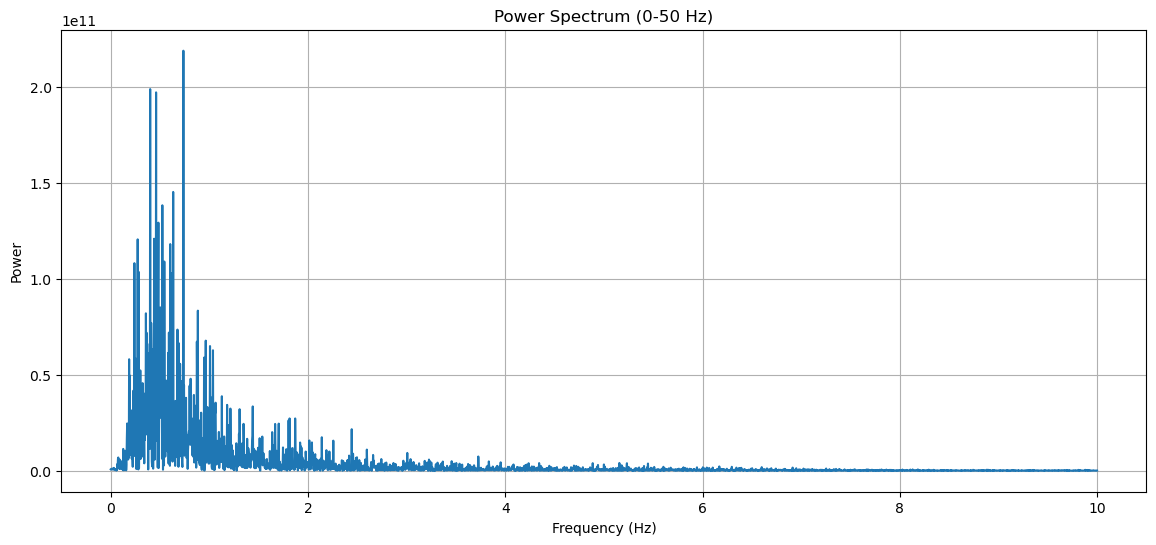

In [ ]:
# Compute FFT and frequencies
fft = np.fft.fft(df["Fp1"])  # Perform FFT
frequencies = np.fft.fftfreq(len(df["Fp1"]), 1/500)  # Frequency axis (Fs = 500 Hz)

# Find the index where frequency is closest to 50 Hz
max_index = np.argmax(frequencies > 10)  # First index exceeding 50 Hz

# Truncate arrays to include only 0-50 Hz
frequencies = frequencies[:max_index]
fft = fft[:max_index]

plt.figure(figsize=(14, 6))

# Plot the power spectrum
plt.plot(frequencies, np.abs(fft)**2)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.title("Power Spectrum (0-50 Hz)")
plt.grid()
plt.show()


### below is single experimentation

In [ ]:
df = pd.read_csv("dataset/derivative_mid_5min/sub-001.csv")

# Compute FFT and frequencies
fft = np.fft.fft(df["Fp1"])  # Perform FFT
frequencies = np.fft.fftfreq(len(df["Fp1"]), 1/500)  # Frequency axis (Fs = 500 Hz)

# Find the index where frequency is closest to 50 Hz
max_index = np.argmax(frequencies > 10)  # First index exceeding 50 Hz

# Truncate arrays to include only 0-50 Hz
frequencies = frequencies[:max_index]
fft = fft[:max_index]

In [ ]:
bins = np.array([0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.4, 2.8, 3.2, 3.6, 4.0, 5.0, 6.0, 9.0, 9.5, 10.0, 10.5, 11.0])

freq_fft = pd.DataFrame([frequencies, fft]).T
freq_fft.columns = ["Frequency", "FFT"]

In [ ]:
# Ensure the Frequency column is real-valued (convert from complex if necessary)
freq_fft["Real_Frequency"] = freq_fft["Frequency"].apply(lambda x: x.real)

# Bin the frequency values
freq_fft["Bin"] = pd.cut(freq_fft["Real_Frequency"], bins=bins, right=False)

# Sum the FFT values (magnitude) within each bin
binned_sums = freq_fft.groupby("Bin", observed=False)["FFT"].sum().reset_index()

# Rename columns
binned_sums.columns = ["Bin", "Sum_FFT_subject001"]

# Define the electrode name
electrode = "FP1"

# Format the bin column into the desired format
binned_sums["Electrode_Bin"] = binned_sums["Bin"].apply(lambda x: f"{electrode}_{x.left:.1f}_{x.right:.1f}".replace(".", ""))
# FP1_00_02 stands for the bin [0.0, 0.2), FP1_100_105 for [10.0, 10.5)

# Drop the original Bin column
binned_sums = binned_sums[["Electrode_Bin", "Sum_FFT_subject001"]]
# binned_sums
transposed_df = binned_sums.set_index("Electrode_Bin").T
transposed_df


Electrode_Bin,FP1_00_02,FP1_02_04,FP1_04_06,FP1_06_08,FP1_08_10,FP1_10_12,FP1_12_14,FP1_14_16,FP1_16_18,FP1_18_20,...,FP1_28_32,FP1_32_36,FP1_36_40,FP1_40_50,FP1_50_60,FP1_60_90,FP1_90_95,FP1_95_100,FP1_100_105,FP1_105_110
Sum_FFT_subject001,9.578821e+05+9.047805e+ 05j,1.060134e+06-6.908121e+ 05j,-1.524926e+06-8.604858e+ 05j,54733.527590-859215.464493j,1.071863e+05-1.002619e+ 06j,638724.606169-157464.500399j,-92894.248769+531991.932952j,-76771.175054+269561.700886j,341241.965321+109253.395969j,-7.884727e+05-9.438604e+ 05j,...,-296959.144907-101719.524127j,351859.591133- 38864.374428j,-112998.482848-397052.924116j,-333533.336882-790928.629744j,175742.685404-151427.339785j,188479.991384-276400.329801j,-103102.042478+ 32884.016431j,-11729.755626-133044.394439j,5629.896429+6347.036634j,0.0+0.0j


In [ ]:
merged_df = pd.concat([pd.DataFrame(), transposed_df], axis=1)
merged_df

Electrode_Bin,FP1_00_02,FP1_02_04,FP1_04_06,FP1_06_08,FP1_08_10,FP1_10_12,FP1_12_14,FP1_14_16,FP1_16_18,FP1_18_20,...,FP1_28_32,FP1_32_36,FP1_36_40,FP1_40_50,FP1_50_60,FP1_60_90,FP1_90_95,FP1_95_100,FP1_100_105,FP1_105_110
Sum_FFT_subject001,9.578821e+05+9.047805e+ 05j,1.060134e+06-6.908121e+ 05j,-1.524926e+06-8.604858e+ 05j,54733.527590-859215.464493j,1.071863e+05-1.002619e+ 06j,638724.606169-157464.500399j,-92894.248769+531991.932952j,-76771.175054+269561.700886j,341241.965321+109253.395969j,-7.884727e+05-9.438604e+ 05j,...,-296959.144907-101719.524127j,351859.591133- 38864.374428j,-112998.482848-397052.924116j,-333533.336882-790928.629744j,175742.685404-151427.339785j,188479.991384-276400.329801j,-103102.042478+ 32884.016431j,-11729.755626-133044.394439j,5629.896429+6347.036634j,0.0+0.0j


## Feature Extraction

In [2]:
bins = np.array([0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.4, 2.8, 3.2, 3.6, 4.0, 5.0, 6.0, 9.0, 9.5, 10.0, 10.5, 11.0])

In [6]:
all_subjects_fft_merged_1_9 = pd.DataFrame()
for i in range(1, 10):
    subject_fft_merged = pd.DataFrame()
    df = pd.read_csv(f"dataset/derivative_mid_5min/sub-00{i}.csv")
    for electrode in df.columns:
        fft = np.fft.fft(df[electrode])  # Perform FFT
        frequencies = np.fft.fftfreq(len(df[electrode]), 1/500)  # Frequency axis (Fs = 500 Hz)
        max_index = np.argmax(frequencies > 10)  # First index exceeding 50 Hz
        frequencies = frequencies[:max_index]
        fft = fft[:max_index]

        freq_fft = pd.DataFrame([frequencies, fft]).T
        freq_fft.columns = ["Frequency", "FFT"]
        # Ensure the Frequency column is real-valued (convert from complex if necessary)
        freq_fft["Real_Frequency"] = freq_fft["Frequency"].apply(lambda x: x.real)

        # Bin the frequency values
        freq_fft["Bin"] = pd.cut(freq_fft["Real_Frequency"], bins=bins, right=False)

        # Sum the FFT values (magnitude) within each bin
        binned_sums = freq_fft.groupby("Bin", observed=False)["FFT"].sum().reset_index()

        # Rename columns
        binned_sums.columns = ["Bin", f"Sum_FFT_Subject_00{i}"]

        # Format the bin column into the desired format
        binned_sums["Electrode_Bin"] = binned_sums["Bin"].apply(lambda x: f"{electrode}_{x.left:.1f}_{x.right:.1f}".replace(".", ""))
        # FP1_00_02 stands for the bin [0.0, 0.2), FP1_100_105 for [10.0, 10.5)

        # Drop the original Bin column
        binned_sums = binned_sums[["Electrode_Bin", f"Sum_FFT_Subject_00{i}"]]

        transposed_df = binned_sums.set_index("Electrode_Bin").T
        subject_fft_merged = pd.concat([subject_fft_merged, transposed_df], axis=1)
    all_subjects_fft_merged_1_9 = pd.concat([all_subjects_fft_merged_1_9, subject_fft_merged], axis=0)

In [7]:
all_subjects_fft_merged_1_9

Electrode_Bin,Fp1_00_02,Fp1_02_04,Fp1_04_06,Fp1_06_08,Fp1_08_10,Fp1_10_12,Fp1_12_14,Fp1_14_16,Fp1_16_18,Fp1_18_20,...,Pz_28_32,Pz_32_36,Pz_36_40,Pz_40_50,Pz_50_60,Pz_60_90,Pz_90_95,Pz_95_100,Pz_100_105,Pz_105_110
Sum_FFT_Subject_001,9.578821e+05+9.047805e+ 05j,1.060134e+06-6.908121e+ 05j,-1.524926e+06-8.604858e+ 05j,5.473353e+04-8.592155e+ 05j,1.071863e+05-1.002619e+ 06j,6.387246e+05-1.574645e+ 05j,-9.289425e+04+5.319919e+ 05j,-7.677118e+04+2.695617e+ 05j,341241.965321+109253.395969j,-7.884727e+05-9.438604e+ 05j,...,-330794.849342-311137.278816j,-23340.094046+ 4586.823419j,-66697.961125-120780.624480j,-178956.460995-791036.353645j,116123.900841-204167.559460j,3.578119e+04-5.563816e+ 05j,43918.954090- 71412.618944j,-27001.983914- 51380.655645j,3662.289831+ 1095.448490j,0.0+0.0j
Sum_FFT_Subject_002,-4.677086e+05-1.564834e+ 04j,7.607428e+05+6.917617e+ 05j,4.561102e+04-7.276671e+ 05j,-5.997487e+04-1.344542e+ 06j,2.981561e+04-9.209594e+ 05j,1.790429e+05+4.749752e+ 05j,2.481858e+05+7.569233e+ 05j,2.280041e+05+5.072869e+ 05j,38242.273737+ 77690.151237j,-2.246331e+05-4.757157e+ 05j,...,-303897.712797-305389.117661j,-321784.428675-159807.073940j,-114018.378774-109745.299987j,113155.496086-716214.048049j,-578910.189492- 13445.510110j,-1.795780e+05-1.012201e+ 06j,137040.306344-128909.769811j,130406.053796-336317.786843j,4194.734156- 2342.891365j,0.0+0.0j
Sum_FFT_Subject_003,2.776134e+05-8.733677e+ 05j,1.554686e+06+2.059148e+ 06j,-7.584599e+05+1.714689e+ 06j,-1.443721e+06+1.555907e+ 06j,9.236264e+05+6.255336e+ 05j,-4.811889e+05-4.938374e+ 05j,-2.532242e+05-1.197273e+ 06j,-3.157862e+05+4.224748e+ 05j,-281668.942987+147233.745393j,-8.031387e+05-5.413313e+ 04j,...,167541.319078+458992.885663j,-122648.510323- 48588.478664j,-317065.984622-286935.754257j,-288706.949365+ 1941.004499j,196362.541230- 49971.432830j,-1.007727e+05+4.419564e+ 03j,118210.953351+539354.826898j,-141460.786495- 78751.764244j,6585.281463- 8769.838250j,0.0+0.0j
Sum_FFT_Subject_004,5.944625e+05-2.667645e+ 05j,7.893959e+05+3.169367e+ 05j,8.969084e+05-5.351972e+ 05j,-2.780739e+05-1.026961e+ 06j,8.335914e+05-5.462042e+ 04j,-9.032931e+05-1.054149e+ 06j,-5.261199e+05+5.703209e+ 05j,-5.230615e+04-7.963269e+ 05j,-331854.296034-519917.462401j,-1.324891e+04+5.111361e+ 05j,...,192189.041887-202196.934298j,-38099.698665+208945.471544j,197427.086932+261731.265295j,-91702.617295+216532.126300j,304926.187995-141659.114157j,4.661084e+04+2.834191e+ 05j,26995.839407+ 45234.804469j,-1904.273906+122798.991715j,-3236.988893- 48.696983j,0.0+0.0j
Sum_FFT_Subject_005,-5.292516e+05-1.501799e+ 06j,-2.777762e+05+8.614394e+ 05j,5.618576e+05-1.587701e+ 06j,5.821914e+05-1.431916e+ 06j,3.519242e+04+3.386738e+ 05j,-8.751001e+05+1.695520e+ 06j,-8.273314e+05-7.613711e+ 04j,-3.256441e+05+1.187894e+ 06j,407328.321102-264359.715997j,-2.951813e+05+9.062864e+ 05j,...,-286399.207143+231506.745980j,205765.187034- 24942.795603j,-243028.847898+497738.329806j,361389.353315+245854.964117j,16505.333941- 39781.136038j,1.741269e+05+6.391912e+ 05j,-152351.373180+126832.905519j,-6371.514651+145601.808639j,-13767.747857- 9497.039111j,0.0+0.0j
Sum_FFT_Subject_006,4.691582e+05+4.372116e+ 05j,-8.153470e+05+1.723502e+ 06j,-9.173360e+05-5.821459e+ 05j,-2.855548e+05+1.532400e+ 05j,7.848221e+05+2.664073e+ 05j,-6.047740e+05+5.389329e+ 05j,-3.463253e+05-1.549238e+ 05j,-6.848734e+04-7.599238e+ 02j,-582657.098027-663778.243705j,-2.994862e+05+1.449064e+ 04j,...,250361.704258+ 40149.716307j,-162828.297976+ 76733.907208j,317478.954435+205667.905793j,417423.052901-132889.692955j,129424.124240-291430.687705j,-2.743068e+05-3.587192e+ 05j,119659.246287- 94728.342216j,37125.213727- 7558.177806j,2084.189597- 6610.357827j,0.0+0.0j
Sum_FFT_Subject_007,7.319759e+05-8.860386e+ 05j,9.298181e+05-5.718975e+ 05j,-1.455364e+06+2.119050e+ 06j,1.048380e+06-4.896000e+ 05j,-2.038676e+06+5.726967e+ 05j,-2.956986e+05+5.595534e+ 05j,6.602722e+04-7.706786e+ 05j,-8.326221e+05-3.682020e+ 05j,289605.297373+750248.481648j,8.600546e+03-2.680081e+ 05j,...,-83087.504

In [8]:
all_subjects_fft_merged_10_88 = pd.DataFrame()
for i in range(10, 89):
    subject_fft_merged = pd.DataFrame()
    df = pd.read_csv(f"dataset/derivative_mid_5min/sub-0{i}.csv")
    for electrode in df.columns:
        fft = np.fft.fft(df[electrode])  # Perform FFT
        frequencies = np.fft.fftfreq(len(df[electrode]), 1/500)  # Frequency axis (Fs = 500 Hz)
        max_index = np.argmax(frequencies > 10)  # First index exceeding 50 Hz
        frequencies = frequencies[:max_index]
        fft = fft[:max_index]

        freq_fft = pd.DataFrame([frequencies, fft]).T
        freq_fft.columns = ["Frequency", "FFT"]
        # Ensure the Frequency column is real-valued (convert from complex if necessary)
        freq_fft["Real_Frequency"] = freq_fft["Frequency"].apply(lambda x: x.real)

        # Bin the frequency values
        freq_fft["Bin"] = pd.cut(freq_fft["Real_Frequency"], bins=bins, right=False)

        # Sum the FFT values (magnitude) within each bin
        binned_sums = freq_fft.groupby("Bin", observed=False)["FFT"].sum().reset_index()

        # Rename columns
        binned_sums.columns = ["Bin", f"Sum_FFT_Subject_0{i}"]

        # Format the bin column into the desired format
        binned_sums["Electrode_Bin"] = binned_sums["Bin"].apply(lambda x: f"{electrode}_{x.left:.1f}_{x.right:.1f}".replace(".", ""))
        # FP1_00_02 stands for the bin [0.0, 0.2), FP1_100_105 for [10.0, 10.5)

        # Drop the original Bin column
        binned_sums = binned_sums[["Electrode_Bin", f"Sum_FFT_Subject_0{i}"]]

        transposed_df = binned_sums.set_index("Electrode_Bin").T
        subject_fft_merged = pd.concat([subject_fft_merged, transposed_df], axis=1)
    all_subjects_fft_merged_10_88 = pd.concat([all_subjects_fft_merged_10_88, subject_fft_merged], axis=0)

In [9]:
all_subjects_fft_merged_10_88

Electrode_Bin,Fp1_00_02,Fp1_02_04,Fp1_04_06,Fp1_06_08,Fp1_08_10,Fp1_10_12,Fp1_12_14,Fp1_14_16,Fp1_16_18,Fp1_18_20,...,Pz_28_32,Pz_32_36,Pz_36_40,Pz_40_50,Pz_50_60,Pz_60_90,Pz_90_95,Pz_95_100,Pz_100_105,Pz_105_110
Sum_FFT_Subject_010,-9.627842e+05+2.338445e+ 05j,6.465619e+04-1.113553e+ 06j,-2.614390e+06-4.592064e+ 05j,-2.236771e+05+3.652851e+ 05j,6.254160e+05+3.345770e+ 05j,7.653979e+05+5.615845e+ 05j,-3.654945e+05+1.051187e+ 06j,6.776939e+05+2.330793e+ 04j,6.027037e+05+1.181483e+ 05j,-3.429543e+04+4.574731e+ 04j,...,-100872.103258+212050.940264j,-46482.360761+542545.003908j,-45770.231157-225405.327186j,-21897.070285- 54017.727948j,286867.123610-548297.293435j,563385.448027+116400.210965j,117152.935928- 20819.090928j,-47074.742587+155935.617897j,2733.871780+ 2622.488413j,0.0+0.0j
Sum_FFT_Subject_011,-1.609088e+05+1.312802e+ 05j,-4.259803e+05+1.135704e+ 05j,2.038172e+06-1.989894e+ 06j,-9.910358e+05+4.224943e+ 05j,-7.640220e+05+5.191941e+ 05j,-6.612546e+05+4.841824e+ 04j,-1.070956e+06-9.636421e+ 05j,-6.291349e+05+2.925954e+ 05j,-3.354769e+05+4.719413e+ 05j,5.863676e+05-1.965061e+ 05j,...,539789.471780+163114.728079j,-262596.045909+521204.485821j,45340.496147- 73788.195231j,432075.529918+ 11056.530715j,-212779.898581+ 50184.075716j,-131313.294032+122821.287282j,167736.395555+142157.293335j,-141042.025868-158901.548529j,5034.758102- 8587.766932j,0.0+0.0j
Sum_FFT_Subject_012,1.029263e+06-2.432813e+ 05j,7.753147e+05+3.215498e+ 05j,-1.164571e+06+1.541266e+ 06j,4.424488e+05-8.058823e+ 05j,1.342020e+05-4.393897e+ 05j,4.795688e+05+4.488055e+ 05j,1.806220e+05-1.036074e+ 06j,5.997189e+05-4.703042e+ 05j,1.905170e+05+6.185838e+ 05j,-1.129933e+05+2.436851e+ 05j,...,-151689.521133-709171.082664j,-385658.480834-281043.314606j,14422.704450+246279.961025j,-353438.606918+318476.256130j,111786.598602+387316.251396j,-581454.516349+ 99774.184058j,-63821.508726+ 78496.443308j,182261.604899-108725.816328j,12651.317640+ 5494.982888j,0.0+0.0j
Sum_FFT_Subject_013,7.278522e+05+4.193627e+ 05j,-9.230132e+05-4.422632e+ 05j,7.531435e+05+8.023736e+ 04j,-1.300253e+05+6.334254e+ 05j,-6.770950e+05-5.204045e+ 03j,-2.291992e+04-1.054947e+ 06j,1.165093e+06+2.769620e+ 05j,-7.812681e+05+3.406728e+ 05j,-3.477511e+05+2.358662e+ 05j,1.263601e+04-5.007552e+ 04j,...,-226779.472976-112815.784938j,94757.866852-214783.745906j,322569.955899- 63571.848588j,-348906.372664+186085.574276j,-480492.197187+182056.251144j,-447423.468023+131812.213057j,107601.825779- 21049.140284j,-236344.282757- 4521.232868j,15903.088135- 1402.066614j,0.0+0.0j
Sum_FFT_Subject_014,-1.216763e+06-4.959478e+ 05j,-1.935499e+06+2.490911e+ 06j,2.918521e+05+1.041646e+ 06j,2.706083e+05+9.091807e+ 05j,6.156716e+05-2.480537e+ 05j,1.571470e+06-8.628257e+ 05j,1.162552e+05-2.690720e+ 05j,-2.094189e+05-4.401085e+ 05j,8.488310e+05-6.094351e+ 05j,2.657354e+05+5.203113e+ 05j,...,435535.618334+ 25183.264028j,392544.320257-436168.123472j,10553.083715+ 97534.082108j,-4989.175855-366247.448548j,-19614.769885-369555.423547j,112205.207761- 33097.560982j,47632.439777-216701.626390j,-106481.952630-178856.314729j,-12201.232010+ 9862.683517j,0.0+0.0j
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Sum_FFT_Subject_084,8.459199e+05-7.070074e+ 04j,-6.273245e+05-2.140423e+ 05j,-6.398459e+05+9.594665e+ 05j,-5.716579e+05-9.114647e+ 05j,-2.256053e+05-3.077409e+ 05j,-4.697227e+05+2.996128e+ 04j,-4.606536e+05-1.500065e+ 05j,-1.632689e+05+2.647655e+ 05j,-3.734487e+05-1.963771e+ 04j,3.710661e+04+5.632680e+ 05j,...,322966.350619+568379.164102j,-251400.564410-407723.389600j,-421659.426874-457067.360393j,-188585.710169+ 22168.742069j,-82535.887886+ 60843.580136j,140974.674235-738846.477376j,-142445.315421- 38270.494053j,-4219.334077+ 58386.191311j,8485.586135+10858.209324j,0.0+0.0j
Sum_FFT_Subject_085,6.200190e+05-1.939994e+ 05j,5.476906e+05-7.759667e+ 05j,-6.278379e+05+2.018391e+ 06j,1.377244e+06-3.866126e+ 05j,7.307995e+05+1.552800e+ 06j,3.228163e+05+3.463629e+ 05j,-1.070027e+06-4.744230e+ 04j,6.215831

In [10]:
all_subjects_features = pd.concat([all_subjects_fft_merged_1_9, all_subjects_fft_merged_10_88], axis=0)
all_subjects_features

Electrode_Bin,Fp1_00_02,Fp1_02_04,Fp1_04_06,Fp1_06_08,Fp1_08_10,Fp1_10_12,Fp1_12_14,Fp1_14_16,Fp1_16_18,Fp1_18_20,...,Pz_28_32,Pz_32_36,Pz_36_40,Pz_40_50,Pz_50_60,Pz_60_90,Pz_90_95,Pz_95_100,Pz_100_105,Pz_105_110
Sum_FFT_Subject_001,9.578821e+05+9.047805e+ 05j,1.060134e+06-6.908121e+ 05j,-1.524926e+06-8.604858e+ 05j,5.473353e+04-8.592155e+ 05j,1.071863e+05-1.002619e+ 06j,6.387246e+05-1.574645e+ 05j,-9.289425e+04+5.319919e+ 05j,-7.677118e+04+2.695617e+ 05j,341241.965321+109253.395969j,-7.884727e+05-9.438604e+ 05j,...,-330794.849342-311137.278816j,-23340.094046+ 4586.823419j,-66697.961125-120780.624480j,-178956.460995-791036.353645j,116123.900841-204167.559460j,3.578119e+04-5.563816e+ 05j,43918.954090- 71412.618944j,-27001.983914- 51380.655645j,3662.289831+ 1095.448490j,0.0+0.0j
Sum_FFT_Subject_002,-4.677086e+05-1.564834e+ 04j,7.607428e+05+6.917617e+ 05j,4.561102e+04-7.276671e+ 05j,-5.997487e+04-1.344542e+ 06j,2.981561e+04-9.209594e+ 05j,1.790429e+05+4.749752e+ 05j,2.481858e+05+7.569233e+ 05j,2.280041e+05+5.072869e+ 05j,38242.273737+ 77690.151237j,-2.246331e+05-4.757157e+ 05j,...,-303897.712797-305389.117661j,-321784.428675-159807.073940j,-114018.378774-109745.299987j,113155.496086-716214.048049j,-578910.189492- 13445.510110j,-1.795780e+05-1.012201e+ 06j,137040.306344-128909.769811j,130406.053796-336317.786843j,4194.734156- 2342.891365j,0.0+0.0j
Sum_FFT_Subject_003,2.776134e+05-8.733677e+ 05j,1.554686e+06+2.059148e+ 06j,-7.584599e+05+1.714689e+ 06j,-1.443721e+06+1.555907e+ 06j,9.236264e+05+6.255336e+ 05j,-4.811889e+05-4.938374e+ 05j,-2.532242e+05-1.197273e+ 06j,-3.157862e+05+4.224748e+ 05j,-281668.942987+147233.745393j,-8.031387e+05-5.413313e+ 04j,...,167541.319078+458992.885663j,-122648.510323- 48588.478664j,-317065.984622-286935.754257j,-288706.949365+ 1941.004499j,196362.541230- 49971.432830j,-1.007727e+05+4.419564e+ 03j,118210.953351+539354.826898j,-141460.786495- 78751.764244j,6585.281463- 8769.838250j,0.0+0.0j
Sum_FFT_Subject_004,5.944625e+05-2.667645e+ 05j,7.893959e+05+3.169367e+ 05j,8.969084e+05-5.351972e+ 05j,-2.780739e+05-1.026961e+ 06j,8.335914e+05-5.462042e+ 04j,-9.032931e+05-1.054149e+ 06j,-5.261199e+05+5.703209e+ 05j,-5.230615e+04-7.963269e+ 05j,-331854.296034-519917.462401j,-1.324891e+04+5.111361e+ 05j,...,192189.041887-202196.934298j,-38099.698665+208945.471544j,197427.086932+261731.265295j,-91702.617295+216532.126300j,304926.187995-141659.114157j,4.661084e+04+2.834191e+ 05j,26995.839407+ 45234.804469j,-1904.273906+122798.991715j,-3236.988893- 48.696983j,0.0+0.0j
Sum_FFT_Subject_005,-5.292516e+05-1.501799e+ 06j,-2.777762e+05+8.614394e+ 05j,5.618576e+05-1.587701e+ 06j,5.821914e+05-1.431916e+ 06j,3.519242e+04+3.386738e+ 05j,-8.751001e+05+1.695520e+ 06j,-8.273314e+05-7.613711e+ 04j,-3.256441e+05+1.187894e+ 06j,407328.321102-264359.715997j,-2.951813e+05+9.062864e+ 05j,...,-286399.207143+231506.745980j,205765.187034- 24942.795603j,-243028.847898+497738.329806j,361389.353315+245854.964117j,16505.333941- 39781.136038j,1.741269e+05+6.391912e+ 05j,-152351.373180+126832.905519j,-6371.514651+145601.808639j,-13767.747857- 9497.039111j,0.0+0.0j
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Sum_FFT_Subject_084,8.459199e+05-7.070074e+ 04j,-6.273245e+05-2.140423e+ 05j,-6.398459e+05+9.594665e+ 05j,-5.716579e+05-9.114647e+ 05j,-2.256053e+05-3.077409e+ 05j,-4.697227e+05+2.996128e+ 04j,-4.606536e+05-1.500065e+ 05j,-1.632689e+05+2.647655e+ 05j,-373448.693920- 19637.705807j,3.710661e+04+5.632680e+ 05j,...,322966.350619+568379.164102j,-251400.564410-407723.389600j,-421659.426874-457067.360393j,-188585.710169+ 22168.742069j,-82535.887886+ 60843.580136j,1.409747e+05-7.388465e+ 05j,-142445.315421- 38270.494053j,-4219.334077+ 58386.191311j,8485.586135+10858.209324j,0.0+0.0j
Sum_FFT_Subject_085,6.200190e+05-1.939994e+ 05j,5.476906e+05-7.759667e+ 05j,-6.278379e+05+2.018391e+ 06j,1.377244e+06-3.866126e+ 05j,7.307995e+05+1.552800e+ 06j,3.228163e+05+3.463629e+ 05j,-1.070027e+06-4.744230e+ 04j,6.215831e+

In [ ]:
# For each subject, 
# calculated the features of each electrode (19 electrodes in total), 22 bins per electrode, resulting in 418 features per subject